OpenCV Version: 4.13.0
Завантаження медіа...
Файли успішно завантажені!

Starting Step-by-Step Image Processing...
Starting Video Processing... Saving to local file.
Video processing complete. Saved to: processed_lane_video.mp4

--- Відображення загальної сітки зображень ---


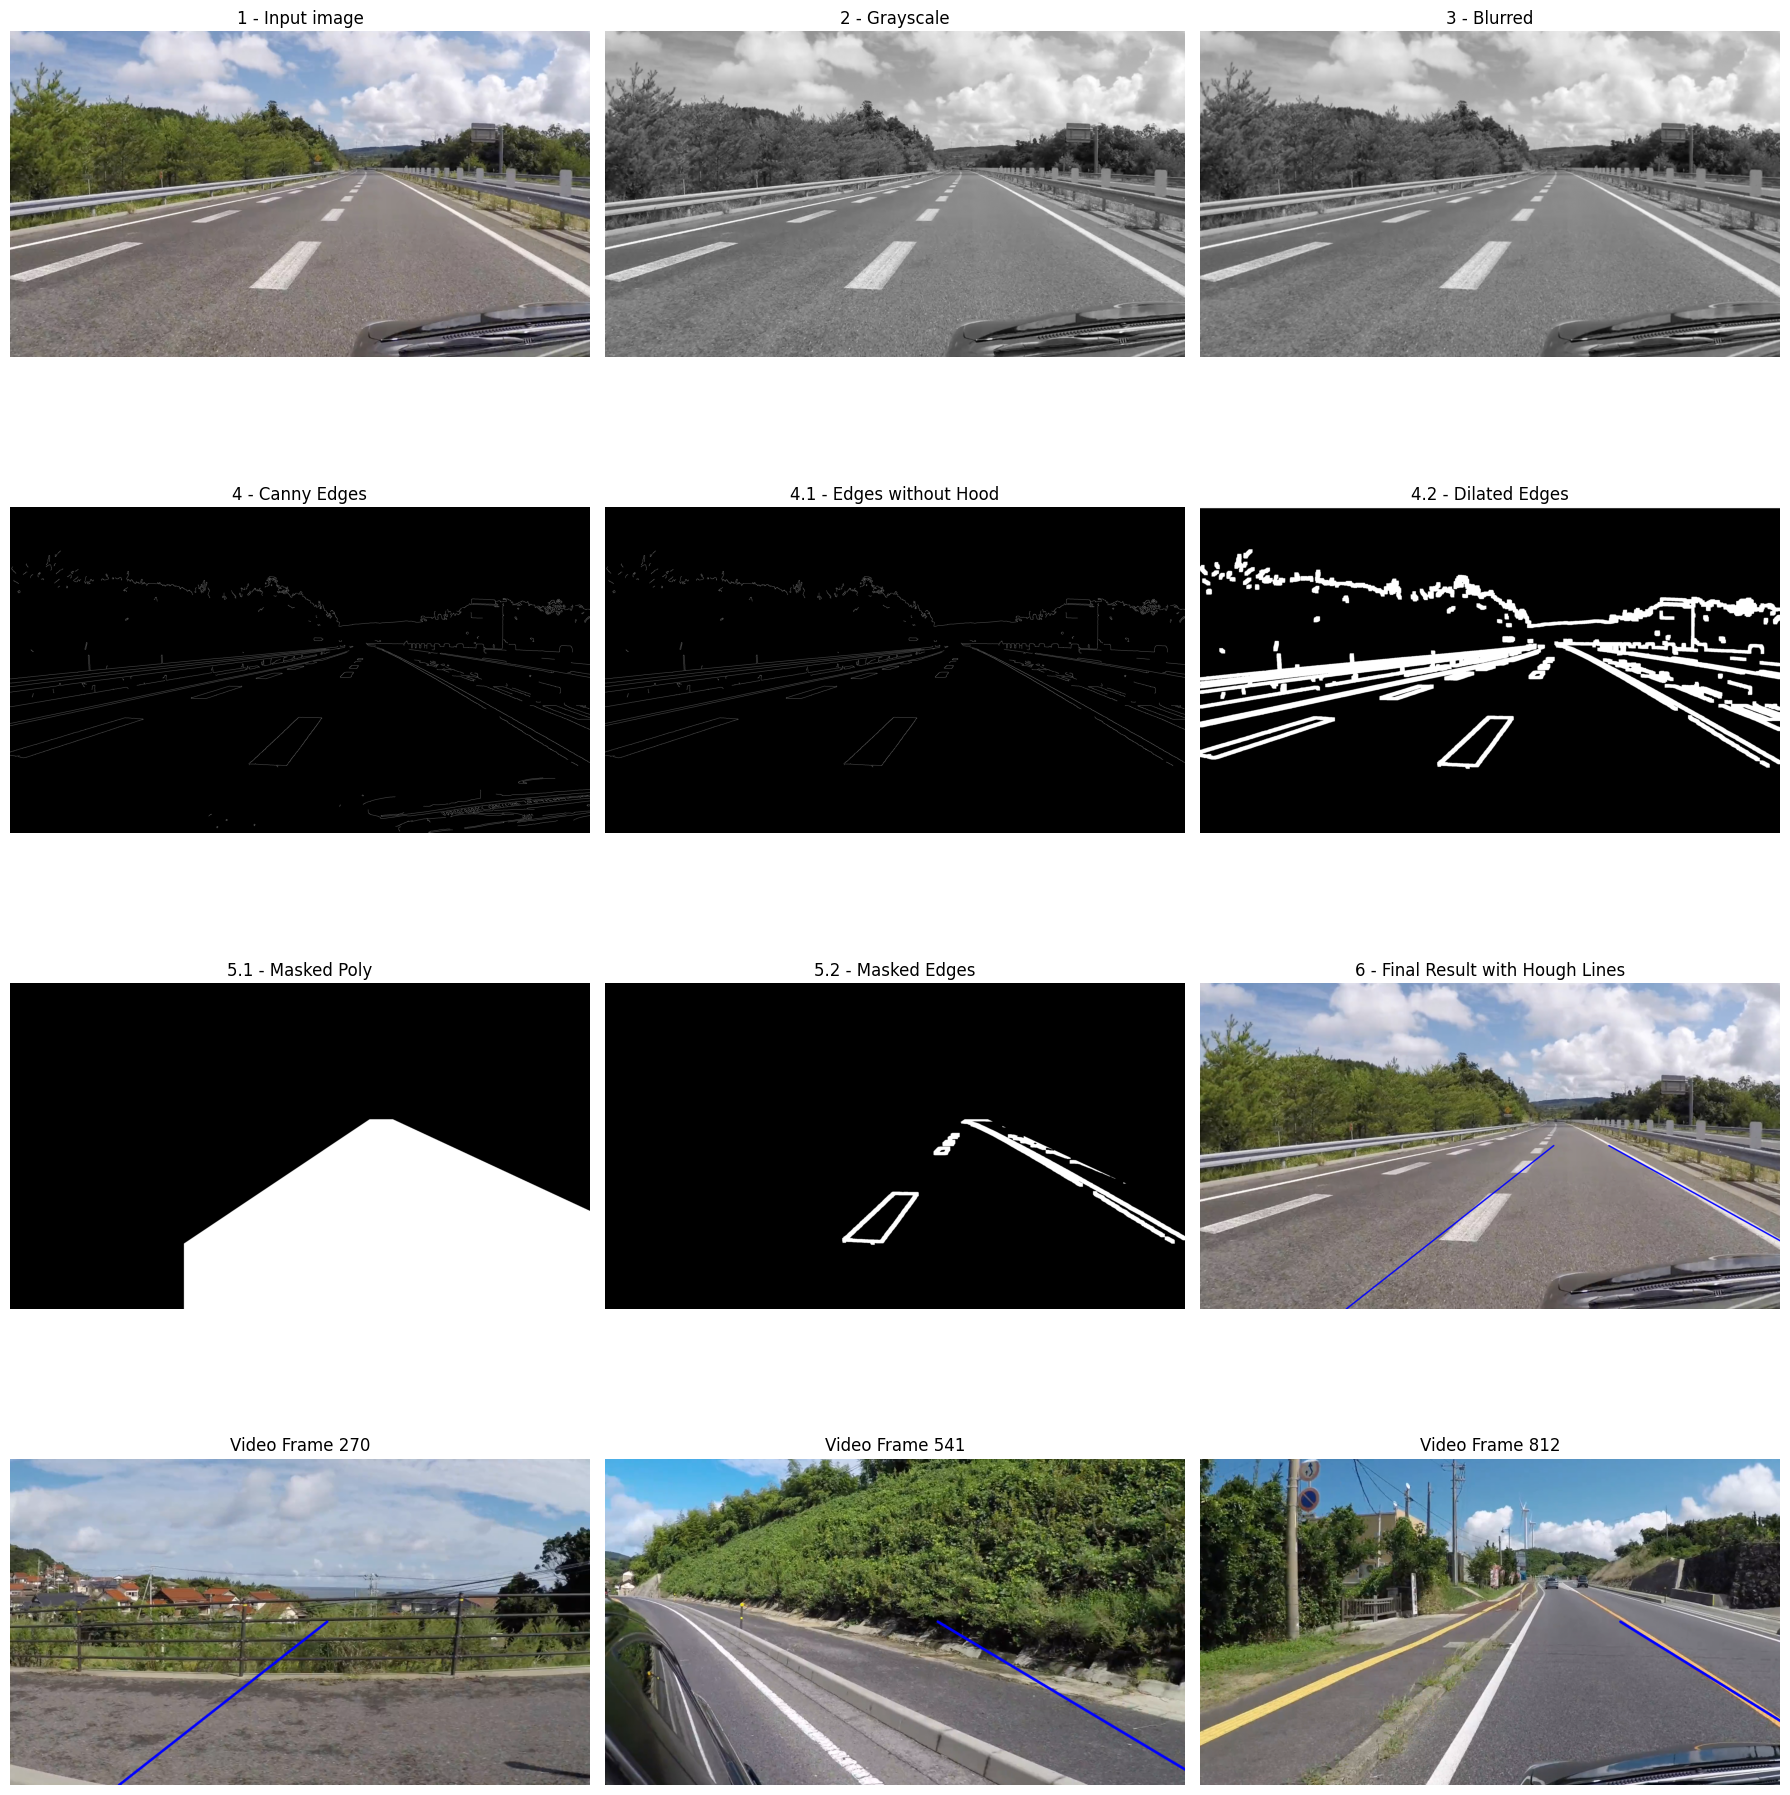


--- Відображення кожного зображення окремо ---



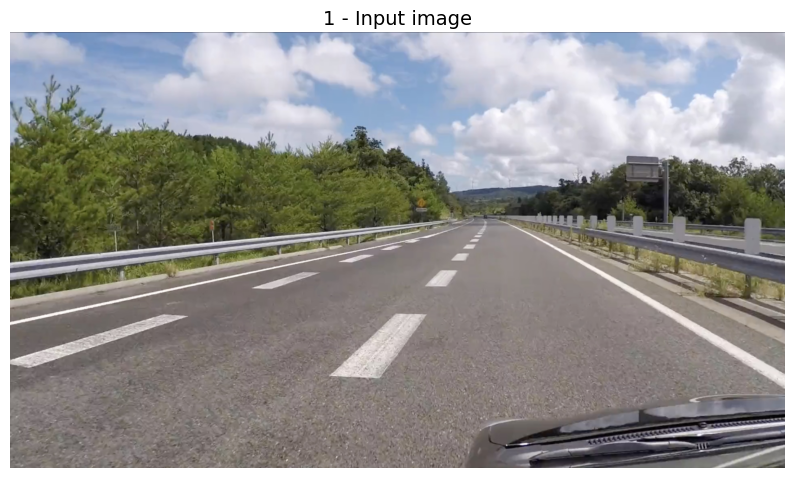

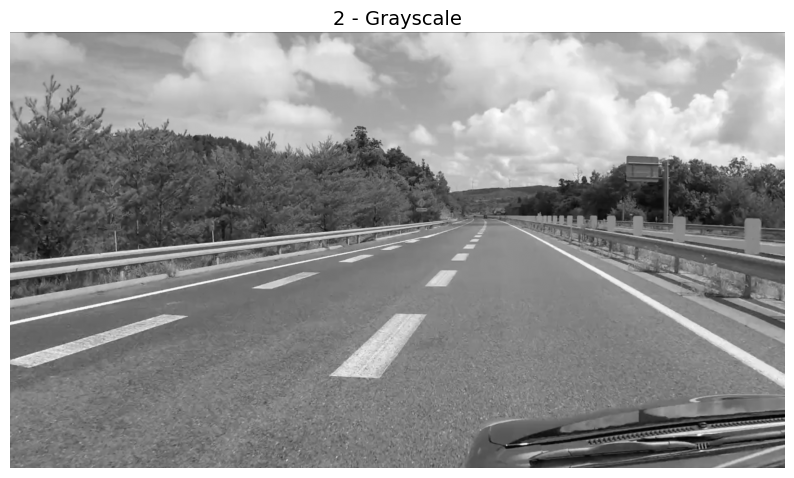

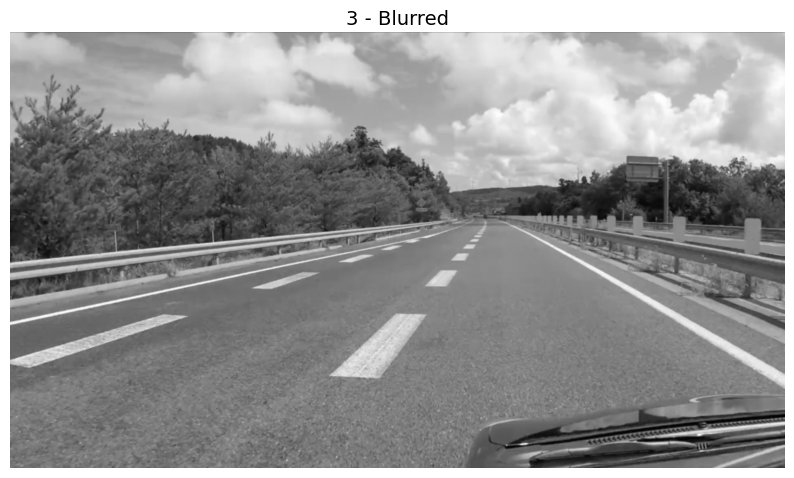

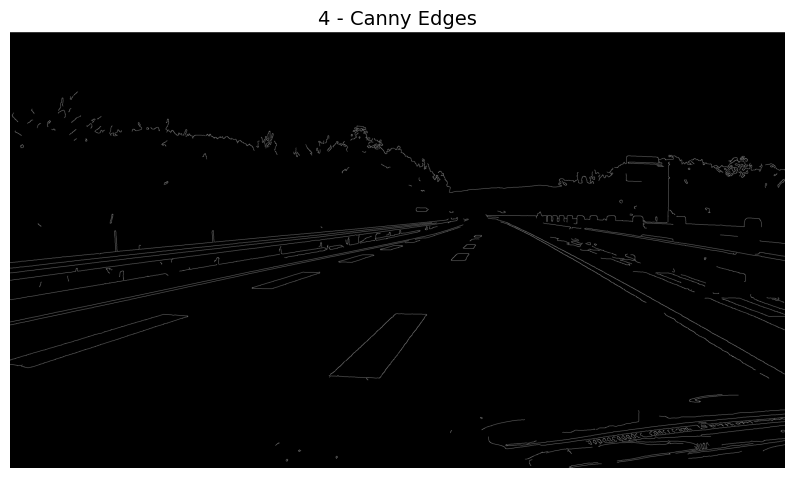

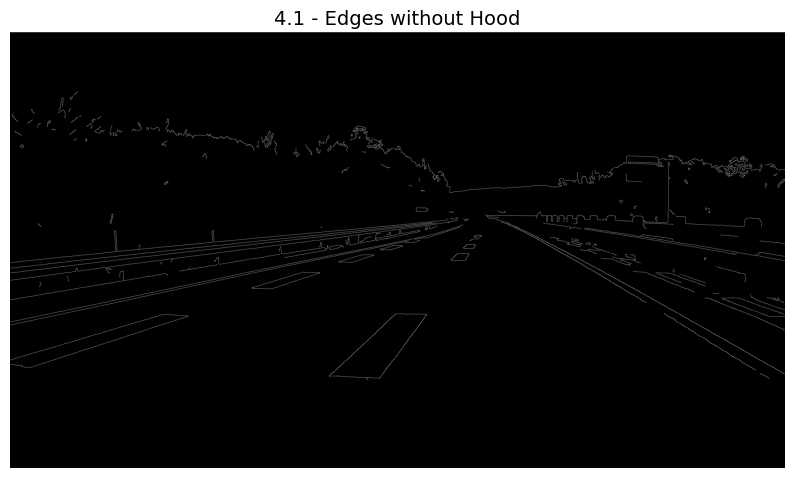

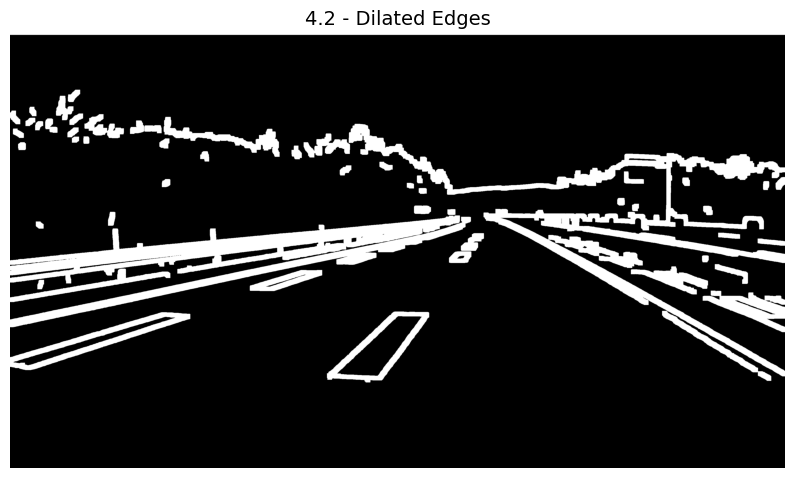

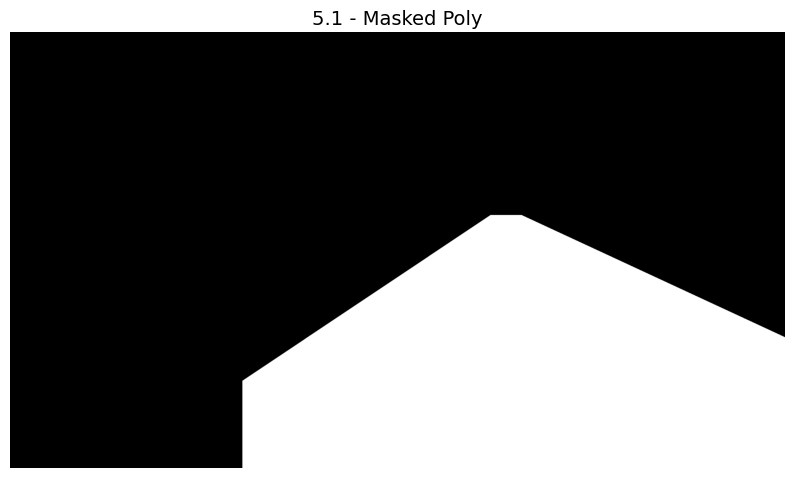

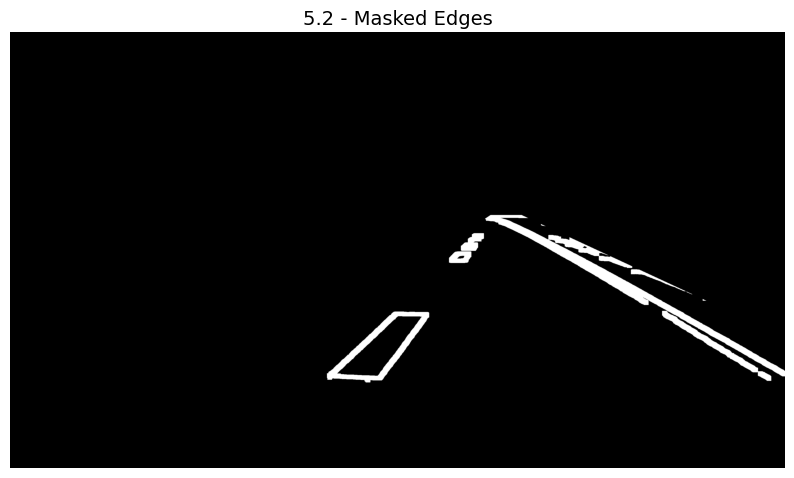

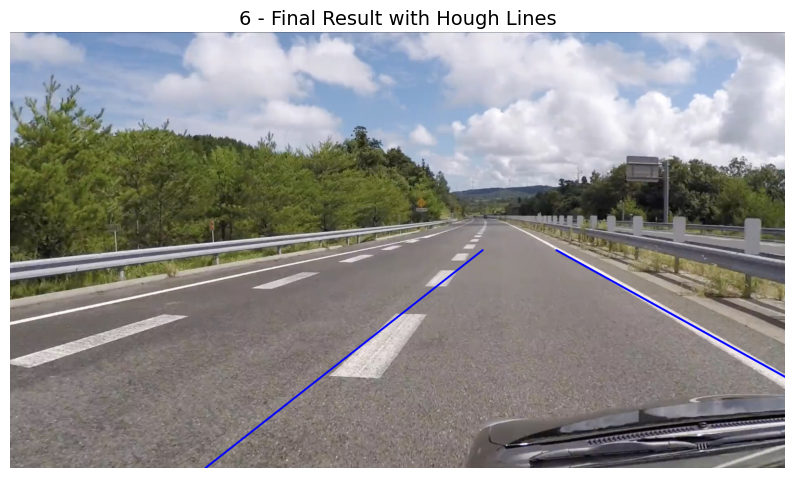

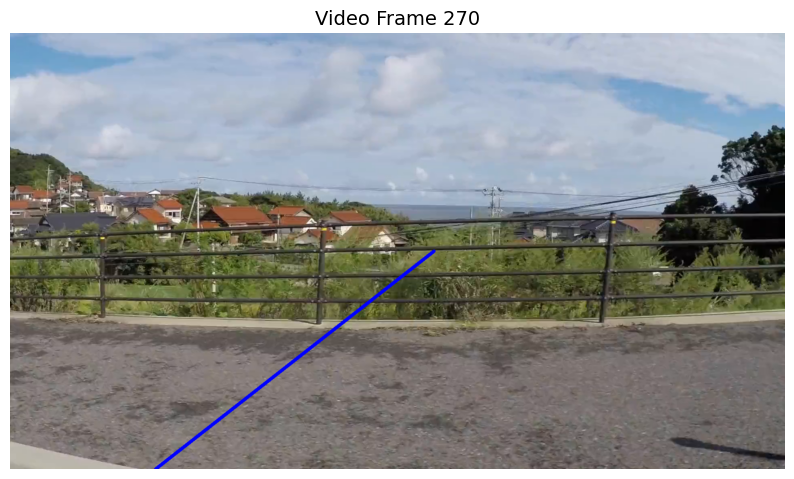

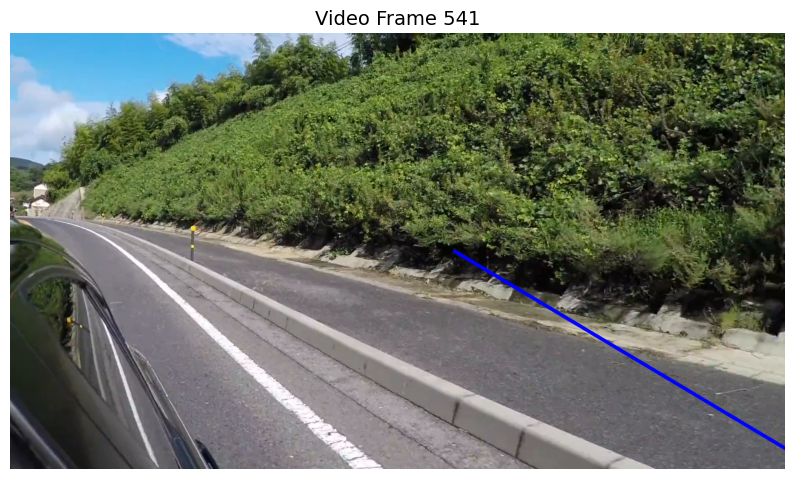

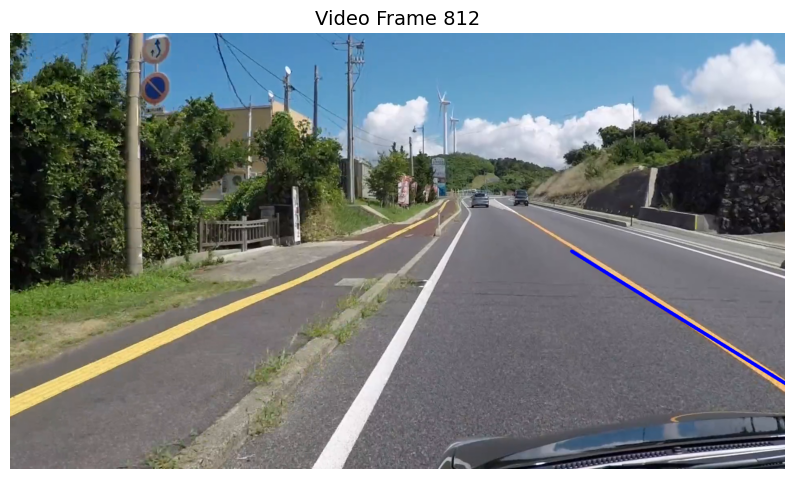

In [1]:
import os
import cv2
import numpy as np
import urllib.request
import matplotlib.pyplot as plt

# 1. --- Перевірка версії OpenCV ---
print("OpenCV Version:", cv2.__version__)

# --- Завантаження файлів з GitHub у робочу директорію Kaggle ---
base_url = "https://raw.githubusercontent.com/YuHryshchenko/zpi-zp41_ai_image_processing_HryshchenkoYuliia_KPI_2026/main/lab03/"

files_to_download = {
    "lane_markings.jpg": "lane_markings.jpg",
    "854669-hd_1920_1080_30fps.mp4": "854669-hd_1920_1080_30fps.mp4"
}

print("Завантаження медіа...")
for filename, save_as in files_to_download.items():
    if not os.path.exists(save_as):
        urllib.request.urlretrieve(base_url + filename, save_as)
print("Файли успішно завантажені!\n")

image_path = 'lane_markings.jpg'
video_path = '854669-hd_1920_1080_30fps.mp4'
output_video_path = 'processed_lane_video.mp4'

# --- ОРИГІНАЛЬНА ФУНКЦІЯ DRAW_LINES ---
def draw_lines(img, lines, color=[255, 0, 0], thickness=7):
    """Calculates average slopes and draws unified left and right lane lines."""
    x_bottom_pos, x_upper_pos = [], []
    x_bottom_neg, x_upper_neg = [], []

    y_bottom = img.shape[0]
    y_upper = int(img.shape[0] * 0.5)

    if lines is not None:
        for line in lines:
            for x1, y1, x2, y2 in line:
                # Prevent division by zero
                if x2 - x1 == 0: 
                    continue
                
                slope = (y2 - y1) / (x2 - x1)
                
                # Test and filter values based on slope to separate left/right lanes
                if 0.5 < slope < 0.8:
                    b = y1 - slope * x1
                    x_bottom_pos.append((y_bottom - b) / slope)
                    x_upper_pos.append((y_upper - b) / slope)
                elif -0.8 < slope < -0.5:
                    b = y1 - slope * x1
                    x_bottom_neg.append((y_bottom - b) / slope)
                    x_upper_neg.append((y_upper - b) / slope)

    # Draw Positive (Right) Line
    if len(x_bottom_pos) > 0 and len(x_upper_pos) > 0:
        cv2.line(img, 
                 (int(np.mean(x_bottom_pos)), int(y_bottom)), 
                 (int(np.mean(x_upper_pos)), int(y_upper)), 
                 color, thickness)

    # Draw Negative (Left) Line
    if len(x_bottom_neg) > 0 and len(x_upper_neg) > 0:
        cv2.line(img, 
                 (int(np.mean(x_bottom_neg)), int(y_bottom)), 
                 (int(np.mean(x_upper_neg)), int(y_upper)), 
                 color, thickness)

# --- ОРИГІНАЛЬНА ОБРОБКА ЗОБРАЖЕННЯ (АДАПТОВАНА ДЛЯ MATPLOTLIB) ---
def process_image(img_path):
    """Processes a single image step-by-step for demonstration."""
    print("Starting Step-by-Step Image Processing...")
    image_steps = []
    
    # 1. Load original image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Error: Could not load image at {img_path}")
        return []
    image_steps.append(('1 - Input image', img.copy()))

    # 2. Convert to Grayscale
    grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    image_steps.append(('2 - Grayscale', grayscale.copy()))

    # 3. Apply Gaussian Blur
    blur_ksize = 9
    blur = cv2.GaussianBlur(grayscale, (blur_ksize, blur_ksize), 0)
    image_steps.append(('3 - Blurred', blur.copy()))

    # 4. Canny Edge Detection
    low_t = 50
    high_t = 150
    edges = cv2.Canny(blur, low_t, high_t)
    image_steps.append(('4 - Canny Edges', edges.copy()))

    # 4.1 Mask out car hood and the dust at the bottom
    h, w = edges.shape[:2]
    cv2.rectangle(edges, (0, int(h * 0.83)), (w, h), 0, -1)
    image_steps.append(('4.1 - Edges without Hood', edges.copy()))

    # 4.2 Dilate edges to make lines thicker
    dilate_ksize = 20
    kernel_dilate = np.ones((dilate_ksize, dilate_ksize), np.uint8)
    dilated_edges = cv2.dilate(edges, kernel_dilate, iterations=1)
    image_steps.append(('4.2 - Dilated Edges', dilated_edges.copy()))

    # 5. Region of Interest (ROI) Mask
    vertices = np.array([
        [
            (int(w * 0.3), h),               # bottom-left
            (w, h),                          # bottom-right
            (w, int(h * 0.7)),               # mid-right (30% up from bottom)
            (int(w * 0.66), int(h * 0.42)),  # top-right
            (int(w * 0.62), int(h * 0.42)),  # top-left
            (int(w * 0.3), int(h * 0.8))     # mid-left (80% up from bottom)
        ]
    ], dtype=np.int32)

    mask = np.zeros_like(edges)
    ignore_mask_color = 255
    masked_poly = cv2.fillPoly(mask, vertices, ignore_mask_color)
    image_steps.append(('5.1 - Masked Poly', masked_poly.copy()))

    masked_edges = cv2.bitwise_and(dilated_edges, mask)
    image_steps.append(('5.2 - Masked Edges', masked_edges.copy()))

    # 6. Hough Transform
    rho = 3
    theta = np.pi / 180
    threshold = 15
    min_line_len = 150
    max_line_gap = 60
    
    lines = cv2.HoughLinesP(masked_edges, rho, theta, threshold, np.array([]), 
                            minLineLength=min_line_len, maxLineGap=max_line_gap)
    
    # 7. Draw Lines on the original image
    result_img = img.copy()
    draw_lines(result_img, lines)
    image_steps.append(('6 - Final Result with Hough Lines', result_img.copy()))
    
    return image_steps

# --- ОРИГІНАЛЬНА ОБРОБКА ВІДЕО (З ДОДАВАННЯМ ЗБЕРЕЖЕННЯ У ФАЙЛ) ---
def process_video(video_path, out_path):
    """Applies the pipeline to a video stream and saves it."""
    print("Starting Video Processing... Saving to local file.")
    video_capture = cv2.VideoCapture(video_path)
    
    # Отримання параметрів відео для збереження
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_capture.get(cv2.CAP_PROP_FPS)
    total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Ініціалізація VideoWriter (кодек mp4v для Kaggle)
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(out_path, fourcc, fps, (width, height))
    
    # Визначаємо кадри для екстракції (наприклад: 25%, 50%, 75% від загальної тривалості)
    target_frames = [total_frames // 4, total_frames // 2, 3 * total_frames // 4]
    extracted_frames = []
    
    frame_count = 0
    while video_capture.isOpened():
        ret, frame = video_capture.read()
        if not ret:
            break
            
        # Inline processing for the video frame (Original Logic)
        blur_ksize = 9
        grayscale = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        blur = cv2.GaussianBlur(grayscale, (blur_ksize, blur_ksize), 0)
        edges = cv2.Canny(blur, 50, 150)
        
        h, w = edges.shape[:2]
        cv2.rectangle(edges, (0, int(h * 0.83)), (w, h), 0, -1)

        dilate_ksize = 20
        kernel_dilate = np.ones((dilate_ksize, dilate_ksize), np.uint8)
        dilated_edges = cv2.dilate(edges, kernel_dilate, iterations=1)

        vertices = np.array([
            [
                (int(w * 0.3), h),               # bottom-left
                (w, h),                          # bottom-right
                (w, int(h * 0.7)),               # mid-right (30% up from bottom)
                (int(w * 0.66), int(h * 0.42)),  # top-right
                (int(w * 0.62), int(h * 0.42)),  # top-left
                (int(w * 0.3), int(h * 0.8))     # mid-left (80% up from bottom)
            ]
        ], dtype=np.int32)

        mask = np.zeros_like(edges)
        cv2.fillPoly(mask, vertices, 255)
        masked_edges = cv2.bitwise_and(dilated_edges, mask)
        
        lines = cv2.HoughLinesP(masked_edges, 3, np.pi / 180, 15, np.array([]), 
                                minLineLength=150, maxLineGap=60)
        
        draw_lines(frame, lines)
        
        # Збереження кадру у новий відеофайл
        out.write(frame)
        
        # Екстракція обраних кадрів для показу в зошиті
        if frame_count in target_frames:
            extracted_frames.append((f"Video Frame {frame_count}", frame.copy()))
            
        frame_count += 1
            
    video_capture.release()
    out.release()
    print(f"Video processing complete. Saved to: {out_path}\n")
    return extracted_frames

# --- ВИКОНАННЯ ---
image_results = process_image(image_path)
video_frames = process_video(video_path, output_video_path)

# Об'єднуємо всі результати в один список для виводу
all_results = image_results + video_frames

# --- ВІДОБРАЖЕННЯ ЗАГАЛЬНОЇ СІТКИ (BIG IMAGE) ---
print("--- Відображення загальної сітки зображень ---")
n_images = len(all_results)
cols = 3
rows = (n_images + 2) // cols

fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()

for i, (title, img) in enumerate(all_results):
    axes[i].set_title(title, fontsize=12)
    # Якщо зображення одноканальне (чорно-біле маска/Canny)
    if len(img.shape) == 2:
        axes[i].imshow(img, cmap='gray')
    # Якщо зображення має 3 канали (BGR), конвертуємо в RGB
    else:
        axes[i].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[i].axis('off')

# Ховаємо порожні рамки
for i in range(n_images, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# --- ВІДОБРАЖЕННЯ КОЖНОГО ЗОБРАЖЕННЯ ОКРЕМО ---
print("\n--- Відображення кожного зображення окремо ---\n")

for title, img in all_results:
    plt.figure(figsize=(10, 10))
    plt.title(title, fontsize=14)
    if len(img.shape) == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()